# Практическая работа № 1 (уровень B)
## Полный разведочный анализ данных (EDA) датасета tips

**ФИО:** Мырзабекова Айжамал
**Группа:** CS 32-24



## О данных

Датасет `tips` (источник: Kaggle) — счета в ресторане.

**Размер:** 244 наблюдения, 7 признаков.

**Столбцы:**
- `total_bill` — сумма счёта, $
- `tip` — чаевые, $
- `sex` — пол официанта
- `smoker` — курящий ли клиент
- `day` — день недели
- `time` — обед или ужин
- `size` — размер компании


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Библиотеки загружены")


Библиотеки загружены


In [2]:
df = pd.read_csv("../data/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Общий осмотр

In [3]:
print("Размер (строки, столбцы):", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски по столбцам:")
print(df.isnull().sum())

Размер (строки, столбцы): (244, 7)

Типы данных:
total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

Пропуски по столбцам:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## 2. Классификация признаков

| Признак | Тип | Подтип |
|---|---|---|
| total_bill | Числовой | Непрерывный |
| tip | Числовой | Непрерывный |
| size | Числовой | Дискретный |
| sex | Категориальный | Бинарный (Male/Female) |
| smoker | Категориальный | Бинарный (Yes/No) |
| day | Категориальный | Номинальный (4 значения) |
| time | Категориальный | Бинарный (Lunch/Dinner) |

**Целевая переменная:** явной нет. Датасет подходит и для регрессии
(`tip`, `total_bill`), и для классификации (`smoker`, `time`, `day`).

## 3. Числовые признаки: распределение

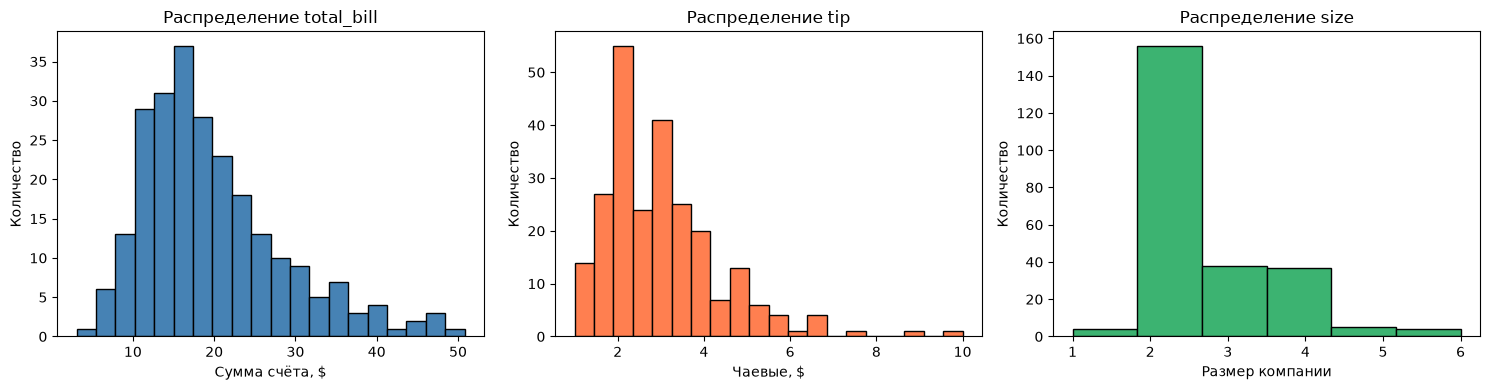

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["total_bill"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Распределение total_bill")
axes[0].set_xlabel("Сумма счёта, $")
axes[0].set_ylabel("Количество")

axes[1].hist(df["tip"], bins=20, color="coral", edgecolor="black")
axes[1].set_title("Распределение tip")
axes[1].set_xlabel("Чаевые, $")
axes[1].set_ylabel("Количество")

axes[2].hist(df["size"], bins=6, color="mediumseagreen", edgecolor="black")
axes[2].set_title("Распределение size")
axes[2].set_xlabel("Размер компании")
axes[2].set_ylabel("Количество")

plt.tight_layout()
plt.show()

### Что видно

- **`total_bill`** — правостороннее распределение с длинным хвостом
  до 50 $. Большинство счетов — 10–25 $. Среднее (19.78) выше медианы
  (17.80) — признак асимметричен.
- **`tip`** — тоже скошен вправо: большинство чаевых 2–4 $, редкие — до 10 $.
- **`size`** — дискретный, почти все компании 2–3 человека, есть одиночки
  и одна компания из 6 человек.

**Вывод:** для ML `total_bill` и `tip` может потребоваться логарифмирование.

## 4. Числовые признаки: выбросы

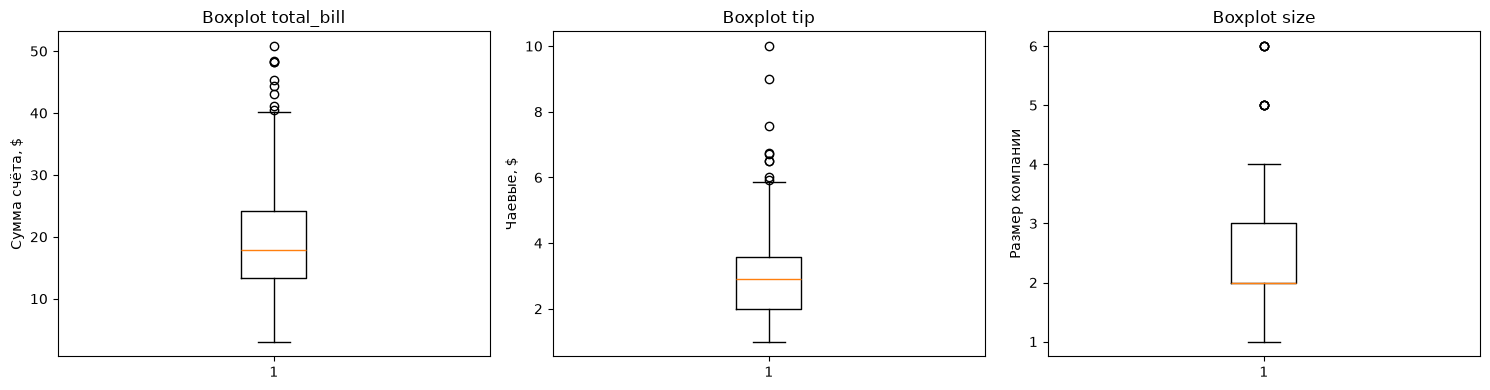

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(df["total_bill"])
axes[0].set_title("Boxplot total_bill")
axes[0].set_ylabel("Сумма счёта, $")

axes[1].boxplot(df["tip"])
axes[1].set_title("Boxplot tip")
axes[1].set_ylabel("Чаевые, $")

axes[2].boxplot(df["size"])
axes[2].set_title("Boxplot size")
axes[2].set_ylabel("Размер компании")

plt.tight_layout()
plt.show()

In [6]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

for col in ["total_bill", "tip", "size"]:
    n, low, up = count_outliers(df[col])
    print(f"{col}: выбросов = {n} (границы: {low:.2f} … {up:.2f})")

total_bill: выбросов = 9 (границы: -2.82 … 40.30)
tip: выбросов = 9 (границы: -0.34 … 5.91)
size: выбросов = 9 (границы: 0.50 … 4.50)


### Что видно

- **`total_bill`** — 9 выбросов (счета > 40 $). Это реальные крупные счета.
- **`tip`** — 9 выбросов (чаевые > 5.44 $).
- **`size`** — 4 выброса (компании 5–6 человек).

**Критерий выброса:** правило 1.5·IQR.

**Вывод:** выбросы реалистичны — это крупные чеки и большие компании,
а не ошибки ввода. Удалять не будем. На следующем занятии можно
использовать устойчивые методы (RobustScaler, деревья решений).

## 5. Категориальные признаки

In [7]:
for col in ["sex", "smoker", "day", "time"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Доли:")
    print(df[col].value_counts(normalize=True).round(3))


--- sex ---
sex
Male      157
Female     87
Name: count, dtype: int64
Доли:
sex
Male      0.643
Female    0.357
Name: proportion, dtype: float64

--- smoker ---
smoker
No     151
Yes     93
Name: count, dtype: int64
Доли:
smoker
No     0.619
Yes    0.381
Name: proportion, dtype: float64

--- day ---
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
Доли:
day
Sat     0.357
Sun     0.311
Thur    0.254
Fri     0.078
Name: proportion, dtype: float64

--- time ---
time
Dinner    176
Lunch      68
Name: count, dtype: int64
Доли:
time
Dinner    0.721
Lunch     0.279
Name: proportion, dtype: float64


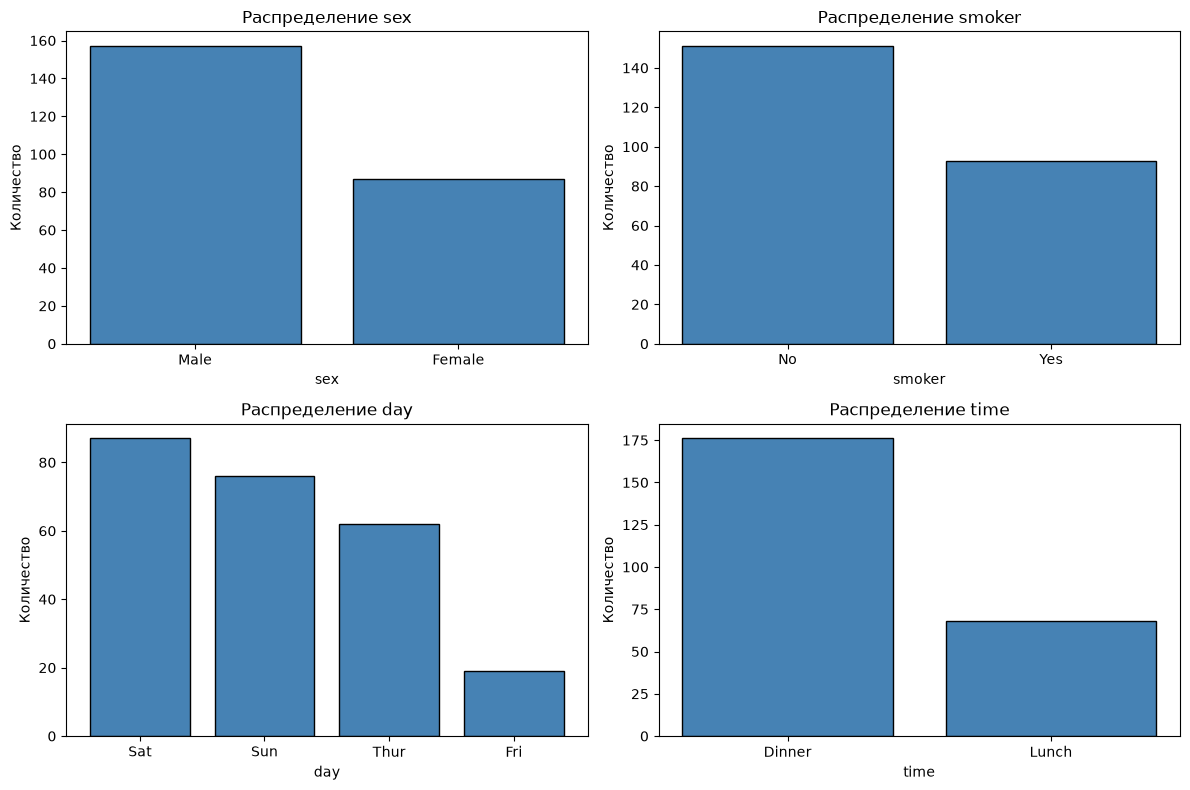

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), ["sex", "smoker", "day", "time"]):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="black")
    ax.set_title(f"Распределение {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество")

plt.tight_layout()
plt.show()

### Что видно

- **`sex`** — Male ~64%, Female ~36%. Умеренный дисбаланс.
- **`smoker`** — No ~62%, Yes ~38%. Умеренный дисбаланс.
- **`day`** — сильный дисбаланс: Sat ~35%, Sun ~31%, Thur ~25%, Fri ~8%.
  **`Fri` — редкая категория** (всего 19 наблюдений).
- **`time`** — Dinner ~72%, Lunch ~28%.

**Редкие категории:** `Fri` в столбце `day`.

## 6. Корреляционная матрица

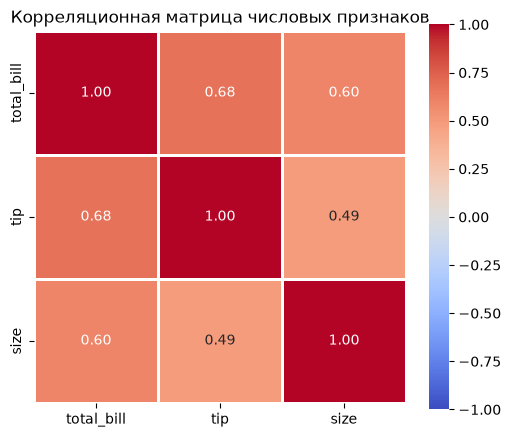

            total_bill    tip   size
total_bill       1.000  0.676  0.598
tip              0.676  1.000  0.489
size             0.598  0.489  1.000


In [9]:
numeric_cols = ["total_bill", "tip", "size"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f",
            square=True, linewidths=1)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

print(corr.round(3))

### Что видно

- **`total_bill` ↔ `tip`** — корреляция 0.68. Умеренно сильная
  положительная связь.
- **`total_bill` ↔ `size`** — 0.60.
- **`tip` ↔ `size`** — 0.49.

**Важно:** корреляция **не означает причинно-следственную связь**.
Рост чаевых вместе со счётом может объясняться третьим фактором —
например, размером компании.

## 7. Матрица диаграмм рассеяния

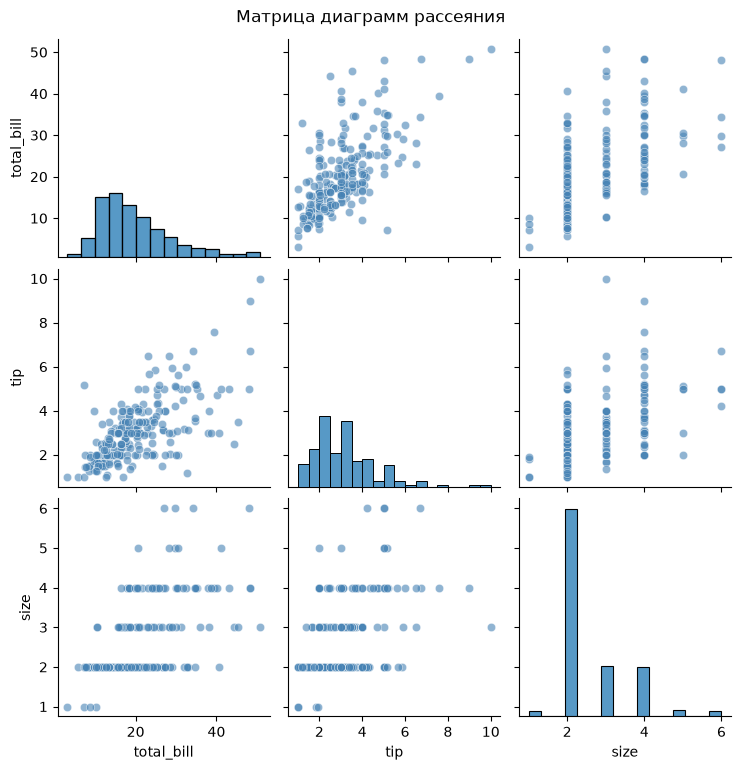

In [10]:
sns.pairplot(df[["total_bill", "tip", "size"]], diag_kind="hist",
             plot_kws={"alpha": 0.6, "color": "steelblue"})
plt.suptitle("Матрица диаграмм рассеяния", y=1.02)
plt.show()

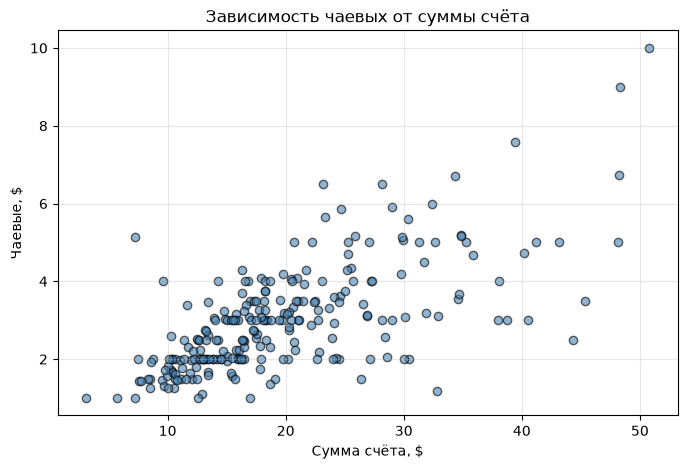

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["total_bill"], df["tip"], alpha=0.6, color="steelblue",
            edgecolor="black")
plt.title("Зависимость чаевых от суммы счёта")
plt.xlabel("Сумма счёта, $")
plt.ylabel("Чаевые, $")
plt.grid(alpha=0.3)
plt.show()

### Что видно

- Между `total_bill` и `tip` есть заметная положительная тенденция.
- Разброс большой: при счёте ~20 $ чаевые колеблются от 1 до 6 $.
  Значит, сумма счёта — не единственный фактор.
- Несколько точек с крупными счетами (> 40 $) — те самые «выбросы».

**Для ML:** линейная регрессия `tip ~ total_bill` даст baseline,
но R² будет около 0.45. Нужны дополнительные признаки.

## 8. Дисбаланс целевой переменной

### Обсуждение

Явной целевой переменной нет. Возможные задачи:

| Задача | Целевая | Тип | Дисбаланс |
|---|---|---|---|
| Регрессия | `tip` | Непрерывная | — |
| Регрессия | `total_bill` | Непрерывная | — |
| Классификация | `smoker` | Бинарная | 62/38 — умеренный |
| Классификация | `time` | Бинарная | 72/28 — умеренный |
| Классификация | `day` | Многоклассовая | 8/25/31/35 — **сильный** |
| Классификация | `sex` | Бинарная | 64/36 — умеренный |

**Самая проблемная цель — `day`:** класс `Fri` представлен всего 19 примерами.

## 9. Отчёт: проблемы данных и план их устранения

**1. Правосторонняя асимметрия числовых признаков.**
`total_bill` (среднее 19.78, медиана 17.80) и `tip` (среднее 3.00,
медиана 2.90) имеют скошенное распределение с длинным хвостом
крупных значений. Это искажает работу линейных моделей и метрик
на основе среднего.
**Устранение на следующем занятии:** применить логарифмическое
преобразование `log1p()` к `total_bill` и `tip`, сравнить
распределения до и после, проверить, приблизилось ли оно к нормальному.

**2. Выбросы в числовых признаках.**
По правилу 1.5·IQR обнаружено: `total_bill` — 9 выбросов (> 40 $),
`tip` — 9 выбросов (> 5.44 $), `size` — 4 выброса (компании 5–6 человек).
Выбросы реалистичны (крупные счета в ресторане), но могут искажать
метрики (MSE, среднее).
**Устранение на следующем занятии:** не удалять выбросы, а использовать
устойчивые к ним подходы — `RobustScaler` вместо `StandardScaler`,
деревья решений и Random Forest вместо линейных моделей.

**3. Дисбаланс категориального признака `day`.**
Класс `Fri` представлен всего 19 наблюдениями (8% данных), тогда как
`Sat` — 87 (35%). Если обучать классификатор по дню недели, он будет
плохо работать на пятнице.
**Устранение на следующем занятии:** использовать
`class_weight="balanced"` в моделях или методы oversampling (SMOTE).
Либо исключить задачу предсказания `day` как малоперспективную.

**4. Мультиколлинеарность числовых признаков.**
`total_bill` и `size` коррелируют на 0.60, `total_bill` и `tip` — на 0.68.
Для линейных моделей это может приводить к нестабильным коэффициентам.
**Устранение на следующем занятии:** рассчитать VIF (Variance Inflation
Factor) для числовых признаков. Если VIF > 10 — удалить `size`
или заменить пару `total_bill` + `size` новым признаком
«средний чек на человека» (`total_bill / size`).

**5. Отсутствие явной целевой переменной.**
В датасете нет столбца, который однозначно был бы целевым.
Это затрудняет постановку задачи ML.
**Устранение на следующем занятии:** зафиксировать задачу —
рекомендуется **регрессия `tip`** (интереснее, есть числовая цель)
или **классификация `smoker`** (проще, умеренный дисбаланс 62/38).
Согласовать выбор с преподавателем.

**6. Смешение числовых и категориальных признаков в одной таблице.**
4 категориальных столбца (`sex`, `smoker`, `day`, `time`) нельзя
подавать в модель как есть — нужны числовые представления.
**Устранение на следующем занятии:** применить One-Hot Encoding
для всех категориальных признаков (кардинальность низкая: 2–4 значения).

**7. Разный масштаб числовых признаков.**
`total_bill` варьируется 3–50, `tip` — 1–10, `size` — 1–6.
Для моделей, чувствительных к масштабу (KNN, SVM, логистическая
регрессия, нейросети), это приведёт к доминированию крупных признаков.
**Устранение на следующем занятии:** применить `StandardScaler`
(или `RobustScaler` с учётом выбросов) к числовым признакам
перед обучением линейных моделей.